In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Trasformazioni: resize a 64x64 e normalizzazione in [0,1]
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()  # ToTensor già porta i valori in [0,1]
])

train_dataset = datasets.Flowers102(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

print("Numero immagini:", len(train_dataset))

# Verifica visiva di un batch
images, _ = next(iter(train_loader))
print("Shape batch:", images.shape)  # atteso: [batch_size, 3, 64, 64]

Device: cuda
Numero immagini: 1020
Shape batch: torch.Size([64, 3, 64, 64])


In [12]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # --- ENCODER ---
        self.enc_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # 64x64 -> 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 16x16 -> 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# 8x8 -> 4x4
            nn.ReLU(),
        )
        self.flatten_dim = 256 * 4 * 4

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # --- DECODER ---
        self.decoder_input = nn.Linear(latent_dim, self.flatten_dim)

        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 16x16 -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # 32x32 -> 64x64
            nn.Sigmoid()  # output in [0,1]
        )

    def encode(self, x):
        h = self.enc_conv(x)
        h = h.view(h.size(0), -1)  # flatten
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(h.size(0), 256, 4, 4)  # reshape per le conv transpose
        x_recon = self.dec_conv(h)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


model = VAE(latent_dim=128).to(device)
print(model)

VAE(
  (enc_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=128, bias=True)
  (decoder_input): Linear(in_features=128, out_features=4096, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 

In [13]:
def vae_loss(x_recon, x, mu, logvar):
    # 1. Reconstruction Loss (BCE, sommata sui pixel, poi mediata sul batch)
    recon_loss = nn.functional.binary_cross_entropy(
        x_recon, x, reduction='sum'
    ) / x.size(0)

    # 2. KL Divergence: KL(N(mu, sigma^2) || N(0, 1))
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_div = kl_div / x.size(0)

    return recon_loss, kl_div

In [14]:
def train_vae(model, train_loader, epochs=30, lr=1e-3, kl_anneal_epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'recon_loss': [], 'kl_loss': [], 'beta': []}

    for epoch in range(epochs):
        model.train()
        epoch_recon = 0.0
        epoch_kl = 0.0

        # Beta cresce linearmente da 0 a 1 durante kl_anneal_epochs, poi resta a 1
        beta = min(1.0, epoch / kl_anneal_epochs)

        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.to(device)

            optimizer.zero_grad()
            x_recon, mu, logvar = model(x)
            recon_loss, kl_loss = vae_loss(x_recon, x, mu, logvar)

            loss = recon_loss + beta * kl_loss
            loss.backward()
            optimizer.step()

            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()

        avg_recon = epoch_recon / len(train_loader)
        avg_kl = epoch_kl / len(train_loader)

        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)
        history['beta'].append(beta)

        print(f"Epoch {epoch+1}/{epochs} | Recon: {avg_recon:.2f} | KL: {avg_kl:.2f} | Beta: {beta:.2f}")

    return history


history = train_vae(model, train_loader, epochs=30, kl_anneal_epochs=10)

Epoch 1/30 | Recon: 8465.75 | KL: 492.85 | Beta: 0.00
Epoch 2/30 | Recon: 8280.45 | KL: 19.23 | Beta: 0.10
Epoch 3/30 | Recon: 7830.31 | KL: 49.79 | Beta: 0.20
Epoch 4/30 | Recon: 7654.08 | KL: 55.95 | Beta: 0.30
Epoch 5/30 | Recon: 7524.91 | KL: 54.97 | Beta: 0.40
Epoch 6/30 | Recon: 7437.03 | KL: 51.60 | Beta: 0.50
Epoch 7/30 | Recon: 7343.73 | KL: 49.94 | Beta: 0.60
Epoch 8/30 | Recon: 7250.37 | KL: 55.49 | Beta: 0.70
Epoch 9/30 | Recon: 7211.99 | KL: 54.85 | Beta: 0.80
Epoch 10/30 | Recon: 7175.06 | KL: 51.81 | Beta: 0.90
Epoch 11/30 | Recon: 7138.07 | KL: 53.63 | Beta: 1.00
Epoch 12/30 | Recon: 7105.36 | KL: 55.02 | Beta: 1.00
Epoch 13/30 | Recon: 7067.46 | KL: 57.29 | Beta: 1.00
Epoch 14/30 | Recon: 7031.83 | KL: 60.06 | Beta: 1.00
Epoch 15/30 | Recon: 6997.76 | KL: 62.56 | Beta: 1.00
Epoch 16/30 | Recon: 6970.49 | KL: 60.39 | Beta: 1.00
Epoch 17/30 | Recon: 6959.62 | KL: 61.85 | Beta: 1.00
Epoch 18/30 | Recon: 6937.42 | KL: 62.84 | Beta: 1.00
Epoch 19/30 | Recon: 6917.50 | KL: 6

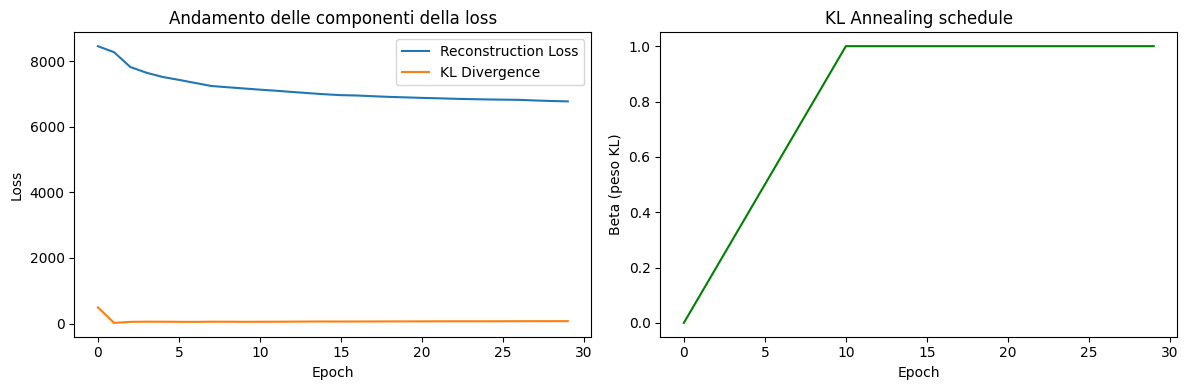

In [15]:
# Plot delle due componenti della loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['recon_loss'], label='Reconstruction Loss')
axes[0].plot(history['kl_loss'], label='KL Divergence')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Andamento delle componenti della loss')

axes[1].plot(history['beta'], color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Beta (peso KL)')
axes[1].set_title('KL Annealing schedule')

plt.tight_layout()
plt.show()

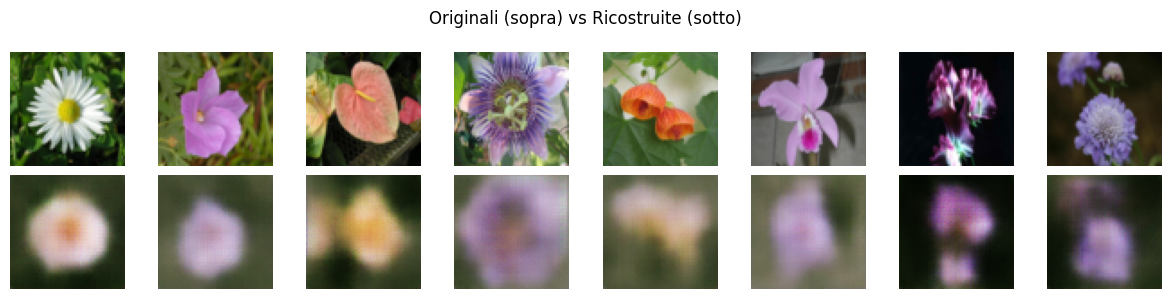

In [16]:
model.eval()

# --- 1. RICOSTRUZIONE: originali vs ricostruite ---
def show_reconstructions(model, data_loader, n=8):
    x, _ = next(iter(data_loader))
    x = x[:n].to(device)

    with torch.no_grad():
        x_recon, _, _ = model(x)

    x = x.cpu()
    x_recon = x_recon.cpu()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i].permute(1, 2, 0))
        axes[0, i].axis('off')
        axes[1, i].imshow(x_recon[i].permute(1, 2, 0))
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Originali', fontsize=10)
    axes[1, 0].set_ylabel('Ricostruite', fontsize=10)
    plt.suptitle('Originali (sopra) vs Ricostruite (sotto)')
    plt.tight_layout()
    plt.show()

show_reconstructions(model, train_loader, n=8)

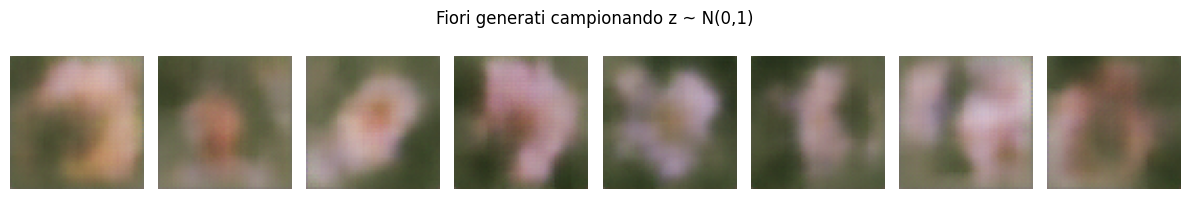

In [17]:
# --- 2. CAMPIONAMENTO: nuove immagini da z casuali ---
def sample_new_images(model, n=8, latent_dim=128):
    with torch.no_grad():
        z = torch.randn(n, latent_dim).to(device)
        samples = model.decode(z).cpu()

    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))
    for i in range(n):
        axes[i].imshow(samples[i].permute(1, 2, 0))
        axes[i].axis('off')
    plt.suptitle('Fiori generati campionando z ~ N(0,1)')
    plt.tight_layout()
    plt.show()

sample_new_images(model, n=8, latent_dim=128)

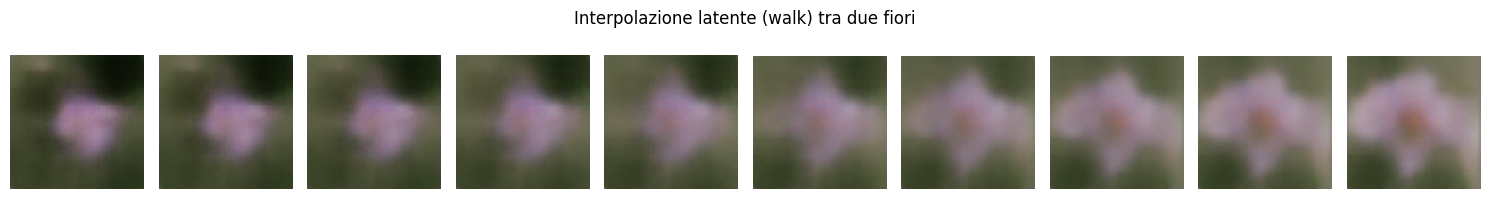

In [18]:
# --- 3. INTERPOLAZIONE LATENTE: walk tra due immagini ---
def latent_interpolation(model, data_loader, n_steps=10):
    x, _ = next(iter(data_loader))
    img1, img2 = x[0:1].to(device), x[1:2].to(device)

    with torch.no_grad():
        mu1, _ = model.encode(img1)
        mu2, _ = model.encode(img2)

        alphas = torch.linspace(0, 1, n_steps).to(device)
        z_interp = torch.stack([mu1.squeeze(0) * (1 - a) + mu2.squeeze(0) * a for a in alphas])

        interpolated = model.decode(z_interp).cpu()

    fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 1.5, 2))
    for i in range(n_steps):
        axes[i].imshow(interpolated[i].permute(1, 2, 0))
        axes[i].axis('off')
    plt.suptitle('Interpolazione latente (walk) tra due fiori')
    plt.tight_layout()
    plt.show()

latent_interpolation(model, train_loader, n_steps=10)